## Aprendizaje No Supervisado

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans

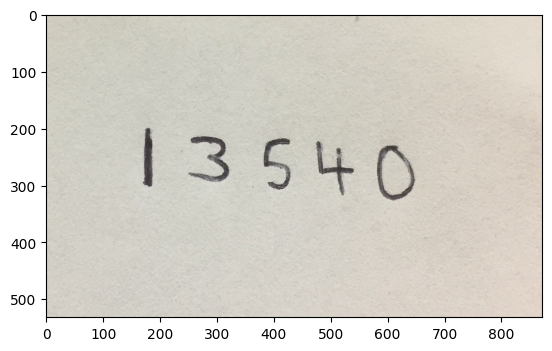

In [108]:
img = cv2.imread("img/numeros_01.jpg")
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.show()

In [109]:
img_data = img_rgb.reshape(-1,3)
img_data.shape

(463904, 3)

In [110]:
km = KMeans(n_clusters=2, random_state=0)
labels = km.fit_predict(img_data)
segmented = labels.reshape(img_rgb.shape[:2])
seg = np.array(segmented)

In [111]:
segmented

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(532, 872), dtype=int32)

In [6]:
seg[segmented == 0] = 0
seg[segmented == 1] = 1
seg[segmented == 2] = 0
seg[segmented == 3] = 0
seg

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(532, 872), dtype=int32)

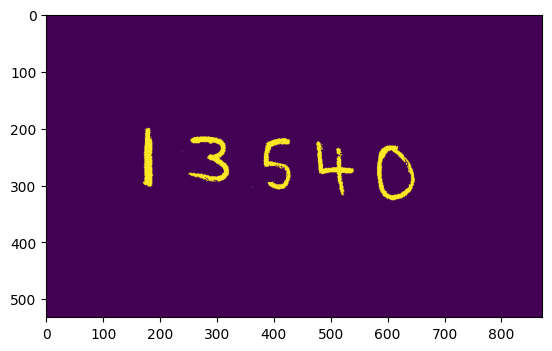

In [112]:
plt.imshow(seg)
plt.show()

In [ ]:
# Ejercicio:
# Usar diferentes espacios de color y observar cómo es la segmentación de la imagen HSV YUV.
# Modificar el número de clústers a buscar en la imagen y observar el comportamiento.
# Investigar metodologías del cómo elegir el número de clústers.

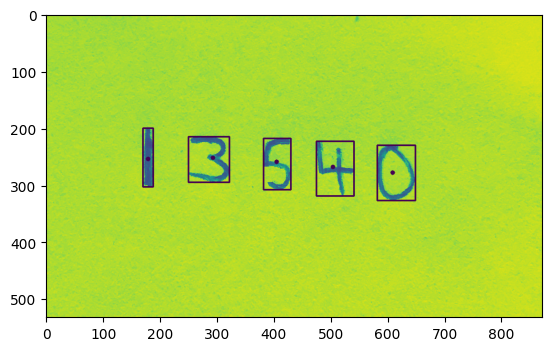

In [118]:
imagen = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
im = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
numeros = []
counter = 0

_, imagen_bin = cv2.threshold(imagen, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
num_labels, labels, stats, centroids = cv2.connectedComponentsWithStats(imagen_bin, 8, ltype=cv2.CV_32S)
for i in range(1, num_labels):
    x = stats[i, cv2.CC_STAT_LEFT]
    y = stats[i, cv2.CC_STAT_TOP]
    w = stats[i, cv2.CC_STAT_WIDTH]
    h = stats[i, cv2.CC_STAT_HEIGHT]
    area = stats[i, cv2.CC_STAT_AREA]
    (cX, cY) = centroids[i]
    if area > 100:
        counter = counter + 1
        numeros.append(im[y-10:y+h+10, x-10:x+w+10])
        cv2.rectangle(imagen, (x, y), (x + w, y + h), (0, 255, 0), 2)
        cv2.circle(imagen, (int(cX), int(cY)), 4, (0, 0, 255), -1)

plt.imshow(imagen)
plt.show()

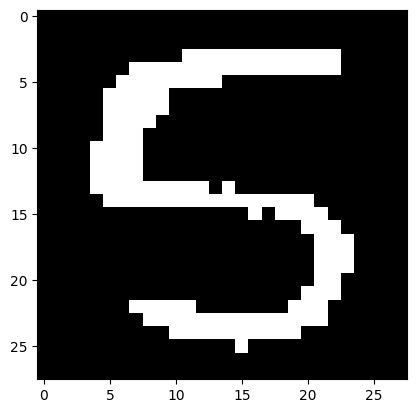

In [123]:
resized_img = cv2.resize(numeros[2], (28, 28))
_, resized_img = cv2.threshold(resized_img, 0, 255, cv2.THRESH_BINARY_INV | cv2.THRESH_OTSU)
img_flat = resized_img.flatten()
plt.imshow(resized_img, cmap="gray")
plt.show()

In [102]:
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split

X, y = fetch_openml('mnist_784', version=1, return_X_y=True, as_frame=False)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=True, random_state=5)

X_train = X_train[:1000]
y_train = y_train[:1000]

X_test = X_test[:1000]
y_test = y_test[:1000]

from sklearn.svm import LinearSVC
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

svm = LinearSVC()
svm.fit(X_train, y_train) # Entrenamiento del modelo

,"penalty penalty: {'l1', 'l2'}, default='l2'Specifies the norm used in the penalization. The 'l2'penalty is the standard used in SVC. The 'l1' leads to ``coef_``vectors that are sparse.",'l2'
,"loss loss: {'hinge', 'squared_hinge'}, default='squared_hinge'Specifies the loss function. 'hinge' is the standard SVM loss(used e.g. by the SVC class) while 'squared_hinge' is thesquare of the hinge loss. The combination of ``penalty='l1'``and ``loss='hinge'`` is not supported.",'squared_hinge'
,"dual dual: ""auto"" or bool, default=""auto""Select the algorithm to either solve the dual or primaloptimization problem. Prefer dual=False when n_samples > n_features.`dual=""auto""` will choose the value of the parameter automatically,based on the values of `n_samples`, `n_features`, `loss`, `multi_class`and `penalty`. If `n_samples` < `n_features` and optimizer supportschosen `loss`, `multi_class` and `penalty`, then dual will be set to True,otherwise it will be set to False... versionchanged:: 1.3 The `""auto""` option is added in version 1.3 and will be the default in version 1.5.",'auto'
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.For an intuitive visualization of the effects of scalingthe regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"multi_class multi_class: {'ovr', 'crammer_singer'}, default='ovr'Determines the multi-class strategy if `y` contains more thantwo classes.``""ovr""`` trains n_classes one-vs-rest classifiers, while``""crammer_singer""`` optimizes a joint objective over all classes.While `crammer_singer` is interesting from a theoretical perspectiveas it is consistent, it is seldom used in practice as it rarely leadsto better accuracy and is more expensive to compute.If ``""crammer_singer""`` is chosen, the options loss, penalty and dualwill be ignored.",'ovr'
,"fit_intercept fit_intercept: bool, default=TrueWhether or not to fit an intercept. If set to True, the feature vectoris extended to include an intercept term: `[x_1, ..., x_n, 1]`, where1 corresponds to the intercept. If set to False, no intercept will beused in calculations (i.e. data is expected to be already centered).",True
,"intercept_scaling intercept_scaling: float, default=1.0When `fit_intercept` is True, the instance vector x becomes ``[x_1,..., x_n, intercept_scaling]``, i.e. a ""synthetic"" feature with aconstant value equal to `intercept_scaling` is appended to the instancevector. The intercept becomes intercept_scaling * synthetic featureweight. Note that liblinear internally penalizes the intercept,treating it like any other term in the feature vector. To reduce theimpact of the regularization on the intercept, the `intercept_scaling`parameter can be set to a value greater than 1; the higher the value of`intercept_scaling`, the lower the impact of regularization on it.Then, the weights become `[w_x_1, ..., w_x_n,w_intercept*intercept_scaling]`, where `w_x_1, ..., w_x_n` representthe feature weights and the intercept weight is scaled by`intercept_scaling`. This scaling allows the intercept term to have adifferent regularization behavior compared to the other features.",1
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to ``class_weight[i]*C`` forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: int, default=0Enable verbose output. Note that this setting takes advantage of aper-process runtime setting in liblinear that, if enabled, may not workproperly in a multithreaded context.",0
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo rand

In [103]:
img_flat.reshape(1,784).shape

(1, 784)

In [124]:
svm.predict(img_flat.reshape(1,784))

array(['3'], dtype=object)